Analytic Task 2 - Player Age and Discipline

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
df = pd.read_csv('Misc_player_stat.csv', encoding='latin1')

In [32]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,...,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
1,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,...,1,0,1,0,1,NaN,NaN,0,Matches,5bc43860
2,2,Thelo Aasgaard,MF,no Norway,24,2002,1,0,0,0,...,3,0,0,3,1,NaN,NaN,0,Matches,c88a28b9
3,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,057d8f12
4,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,...,0,0,0,1,0,NaN,NaN,0,Matches,accbfc94


In [33]:
df = pd.read_csv('Misc_player_stat.csv', encoding='latin1', header=1)

In [34]:
df.head()

,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,...,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,...,1,0,1,0,1,NaN,NaN,0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,...,3,0,0,3,1,NaN,NaN,0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,...,0,0,0,1,0,NaN,NaN,0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,bff15d74


In [35]:
print(df.columns.tolist())

['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'Matches', '-9999']


In [36]:
df = df[['Player', 'Pos', 'Squad', 'Age', '90s', 'Fls']].copy()

In [37]:
df.head()

,Player,Pos,Squad,Age,90s,Fls
0,Brenden Aaronson,MF,us USA,25,0.8,2
1,Thelo Aasgaard,MF,no Norway,24,1.0,0
2,Hamza Abdelkarim,FW,eg Egypt,18,0.7,2
3,Hossam Abdelmaguid,DF,eg Egypt,25,0.7,1
4,Mohamed Abdelmonem,DF,eg Egypt,27,0.2,1


In [38]:
print(df['Age'].astype(str).str.contains('-', na=False).sum()) #checking if age contains any days like 23-174

0


In [39]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') #cleaning column values
df['90s'] = pd.to_numeric(df['90s'], errors='coerce')
df['Fls'] = pd.to_numeric(df['Fls'], errors='coerce')

In [40]:
df = df[~df['Pos'].astype(str).str.contains( 'GK', na=False ) ].copy() #removing goalkeeper due to diff foul profile

In [41]:
df = df[ df['90s'] >= 1.0 ].copy() #removing players with less than 1 90's played

In [42]:
df = df.dropna( subset=['Age', '90s', 'Fls'] )

In [43]:
df['Fouls_Per_90'] = ( df['Fls'] / df['90s'] )

In [44]:
df['Age_Group'] = np.where( df['Age'] <= 23, 'Young (≤23)', 'Older (>23)' )
df['Age_Group'].value_counts()

Age_Group
Older (>23)    563
Young (≤23)    122
Name: count, dtype: int64

In [45]:
df.head()

,Player,Pos,Squad,Age,90s,Fls,Fouls_Per_90,Age_Group
1,Thelo Aasgaard,MF,no Norway,24,1.0,0,0.000000,Older (>23)
5,Ali Abdi,DF,tn Tunisia,32,3.0,4,1.333333,Older (>23)
6,Saud Abdulhamid,DF,sa Saudi Arabia,26,3.0,4,1.333333,Older (>23)
7,Abdulla Abdullaev,DF,uz Uzbekistan,28,2.0,5,2.500000,Older (>23)
8,Yusuf Abdurisag,FW,qa Qatar,26,1.1,1,0.909091,Older (>23)


In [46]:
print("\nAGE GROUP SIZES:") 
print( df['Age_Group'].value_counts() )


AGE GROUP SIZES:
Age_Group
Older (>23)    563
Young (≤23)    122
Name: count, dtype: int64


In [47]:
young = df[ df['Age_Group'] == 'Young (≤23)' ].copy() 
older = df[ df['Age_Group'] == 'Older (>23)' ].copy()

In [48]:
young_sample = young.sample(n=30,random_state=42)
older_sample = older.sample(n=30,random_state=42)
sample = pd.concat([young_sample,older_sample],ignore_index=True)

In [49]:
from scipy import stats
import matplotlib.pyplot as plt

In [50]:
sample.groupby('Age_Group')['Fouls_Per_90'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
Age_Group,,,,,,
Older (>23),30,1.039903,0.816327,1.007770,0.0,4.615385
Young (≤23),30,1.096194,0.916667,0.923099,0.0,3.500000


In [51]:
sample.groupby('Age_Group')['Fouls_Per_90'].agg(
    variance='var',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

,variance,q1,q3,iqr
Age_Group,,,,
Older (>23),1.015600,0.425000,1.275666,0.850666
Young (≤23),0.852112,0.477625,1.655405,1.177781


In [52]:
young_fouls = sample[
    sample['Age_Group'] == 'Young (≤23)'
]['Fouls_Per_90']

older_fouls = sample[
    sample['Age_Group'] == 'Older (>23)'
]['Fouls_Per_90']

In [53]:
young_mean = young_fouls.mean()

young_ci = stats.t.interval(
    confidence=0.95,
    df=len(young_fouls)-1,
    loc=young_mean,
    scale=stats.sem(young_fouls)
)

older_mean = older_fouls.mean()

older_ci = stats.t.interval(
    confidence=0.95,
    df=len(older_fouls)-1,
    loc=older_mean,
    scale=stats.sem(older_fouls)
)

print("Young 95% CI:", young_ci)
print("Older 95% CI:", older_ci)

Young 95% CI: (np.float64(0.7515027126355951), np.float64(1.4408844301763761))
Older 95% CI: (np.float64(0.6635960372457115), np.float64(1.4162107573790679))


In [54]:
t_stat, p_value = stats.ttest_ind(
    young_fouls,
    older_fouls,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.22559959849222813
p-value: 0.8223119756831643


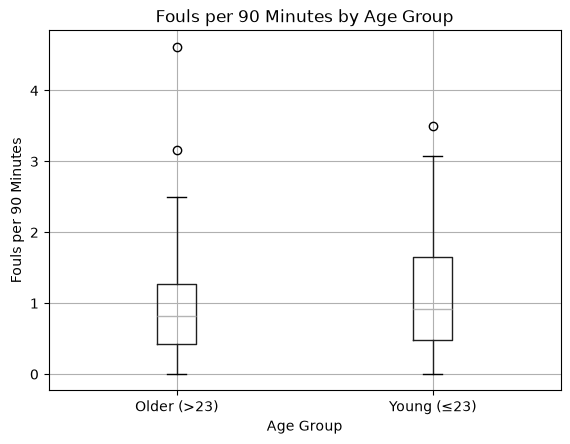

In [55]:
sample.boxplot(
    column='Fouls_Per_90',
    by='Age_Group'
)

plt.title('Fouls per 90 Minutes by Age Group')
plt.suptitle('')
plt.xlabel('Age Group')
plt.ylabel('Fouls per 90 Minutes')
plt.show()

In [56]:
print("Young skewness:", young_fouls.skew())
print("Older skewness:", older_fouls.skew())

Young skewness: 0.8061469263685814
Older skewness: 1.9088662858120702


In [57]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Fail to reject the null hypothesis.


In [58]:
sample.to_csv(
    'sample_cleaned.csv',
    index=False
)